In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json

from src.utils.utils import find_project_root, load_ligand_models 

BASE_DIR = find_project_root()

DATA_DIR = BASE_DIR / "data" / "processed" 

from figures.fig_scripts.fig2_functions import * 

### Loading Noramlized KS-FDR filtered data frame

### Generating processed BMP4 object

4PL Aanlysis of all ligands was done with run_all_ligands_pipeline.py and the saved as .pkl files for easy loading with load_ligand_models

In [3]:
models = load_ligand_models(subset=["BMP4"])
bmp4_model = models["BMP4"]

del models

In [4]:
df = pd.read_parquet(DATA_DIR / "cpm_df.parquet")

### Panel A: 3D PCA


In [5]:
pca_mean_df, _ = perform_pca(bmp4_model.df[bmp4_model.all_genes_list], log_transform=True, epsilon=1)

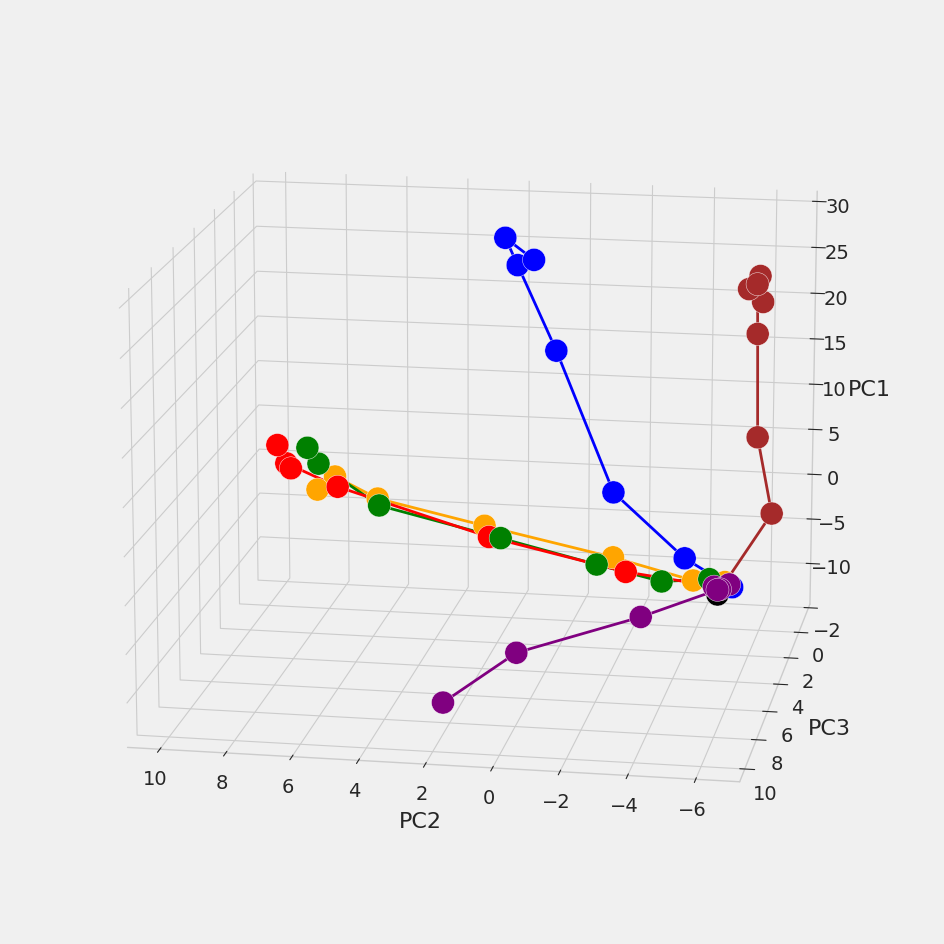

In [6]:
plot_ligand_pca_3d(
    pca_mean_df,
    fig_size=(16, 12),
    label_fontsize=16,
    tick_fontsize=14,
    label_pad=10,
    elev=15,
    azim=100,
    inv_pc_1=False,
    save=False,
)

### Panel B: Hierarchical-clustered heatmap

Load fc_all_genes_df_sig.csv generated by scripts/generate_fc_all_sig_genes.py

In [7]:
fc_all_genes_df = pd.read_parquet(DATA_DIR / "fc_all_genes_df_sig.parquet")

In [8]:
LIGAND_ORDER = ["BMP4", "BMP6", "BMP9", "BMP10", "TGFb1", "GDF5"]
K = 5

results_dict = prepare_kmeans_cluster_data(
    fc_all_genes_df,
    data_cols=LIGAND_ORDER,
    k=K,
)

plot_data = results_dict["plot_data"]
fc_scaled = results_dict["fc_scaled"]

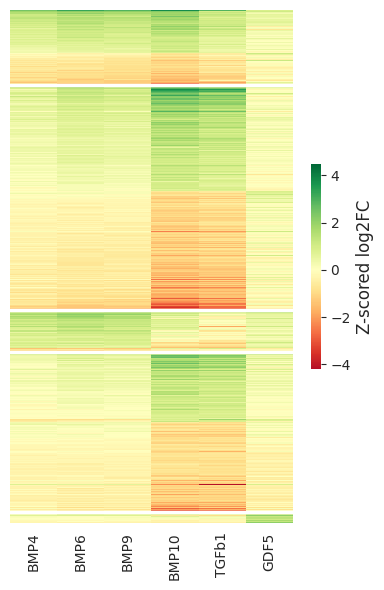

In [9]:
plot_kmeans_heatmap(plot_data, fc_scaled, figsize=(4, 6), k=K, save=False)

### Panel C: Mean Expression per ligand by cluster:

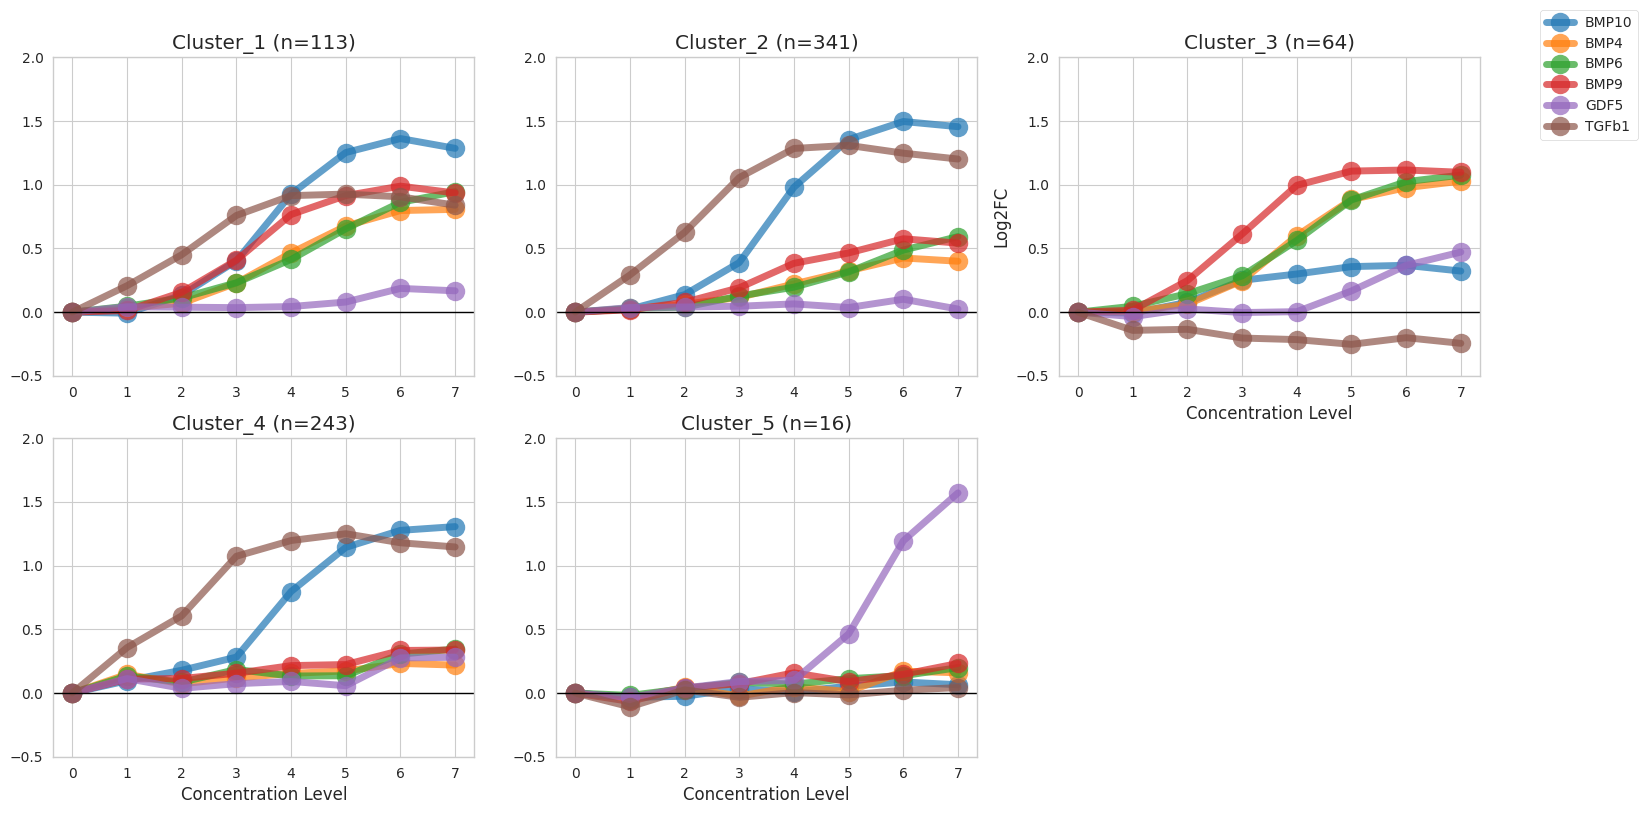

In [18]:
fc_df_sig, sign_df = build_signed_fc_df(bmp4_model.df_fc, plot_data)
gene_clusters_dict = generate_clusters_dict(plot_data)
ligands_df_dict = get_ligands_df_dict(fc_df_sig)

plot_clusters(ligands_df_dict, gene_clusters_dict, save=True)

In [59]:
#save dictionary for later use in panel C
with open(BASE_DIR / "data" / "processed" / "dicts" / "kmeans_5_clusters_dict.json", "w") as f:
    json.dump(gene_clusters_dict, f)

In [60]:
gene_clusters_dict_sep = generate_clusters_dict(plot_data, sign_df=sign_df, separate_up_down=True)

#save dictionary for later use in panel C
with open(BASE_DIR / "data" / "processed" / "dicts" / "kmeans_5_clusters_dict_sep.json", "w") as f:
    json.dump(gene_clusters_dict_sep, f)

### Panel D:  Pair-wise Pearson correlations between the ligands:

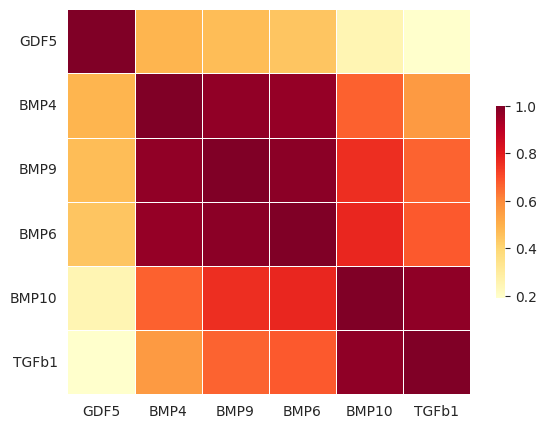

In [56]:
plot_corr_matrix(fc_all_genes_df, save=False)

### Panel E:  Elbow method plot for k-means clustering 

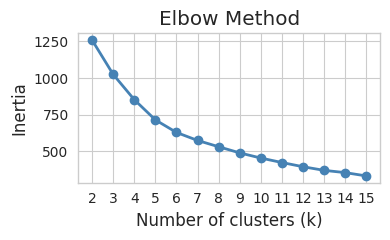

In [57]:
plot_kmeans_elbow(fc_all_genes_df, save=False)